# Análisis de Movies y Tags: Perfilamiento de Películas por Etiquetas

## Introducción

Este notebook cruza la información de **películas** (movies) con las **etiquetas** (tags) que los usuarios les asignan en MovieLens. El objetivo es construir un perfil de cada película y género basado en lo que los usuarios dicen de ellas, proporcionando información valiosa para:

- **Usuarios**: Encontrar películas con características específicas que les interesen.
- **Empleados**: Entender qué se dice de cada tipo de contenido y cómoategorizar el catálogo de forma más efectiva.

### Preguntas clave que este notebook responde:
- ¿Las películas más recientes reciben más tags (más interacción de usuarios)?
- ¿Qué tags son exclusivos de ciertos géneros?
- ¿Qué películas generan más discusión entre los usuarios?
- ¿Qué géneros tienen la mayor diversidad de opiniones?
- ¿Cómo cambian los tags a lo largo de las décadas?
- ¿Existen películas con opiniones contradictorias?
- ¿Cómo se distribuye la cantidad de tags por género?

## Importación de librerías y datos

In [9]:
import os
import sys
import re

project_root = os.path.abspath('../../..')
sys.path.insert(0, os.path.join(project_root, 'src'))

from parcial_digd import utils_

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [11]:
movies = pd.read_csv('../../../data/processed/movies.csv')
movies_with_genres = utils_.get_genre_columns(movies.copy())

tags = pd.read_csv('../../../data/processed/tags.csv')

movies['year'] = pd.to_datetime(movies['release_year']).dt.year.astype(float)
movies['decada'] = (movies['year'] // 10) * 10

print(f'Películas: {len(movies):,}')
print(f'Tags: {len(tags):,}')
print(f'Películas con al menos 1 tag: {tags["movieId"].nunique():,}')
print(f'Tags únicos: {tags["tag"].nunique():,}')

Películas: 86,967
Tags: 1,992,636
Películas con al menos 1 tag: 51,069
Tags únicos: 140,191


In [12]:
tags_per_movie = tags.groupby('movieId').agg(
    total_tags=('tag', 'count'),
    tags_unicos=('tag', 'nunique'),
    lista_tags=('tag', list)
).reset_index()

movies_full = movies.merge(tags_per_movie, on='movieId', how='left')
movies_full['total_tags'] = movies_full['total_tags'].fillna(0).astype(int)
movies_full['tags_unicos'] = movies_full['tags_unicos'].fillna(0).astype(int)

movies_with_any_tag = movies_full[movies_full['total_tags'] > 0]
print(f'Películas con al menos 1 tag: {len(movies_with_any_tag):,}')
print(f'Películas sin tags: {(movies_full["total_tags"] == 0).sum():,}')

Películas con al menos 1 tag: 51,069
Películas sin tags: 35,898


---
## Idea 1: Año de Estreno vs Cantidad de Tags

### Introducción
¿Las películas más recientes reciben más atención por parte de los usuarios en forma de tags? Este análisis examina si existe una relación entre el **año de estreno** de una película y la **cantidad de tags** que recibe, lo cual refleja el nivel de interacción de los usuarios con contenido de diferentes épocas.

### Justificación
Para un **empleado**, saber qué películas recientes generan más discusión permite identificar tendencias de audiencia y contenido popular. Para un **usuario**, las películas con muchos tags suelen tener más información disponible, lo que facilita la decisión de qué ver.

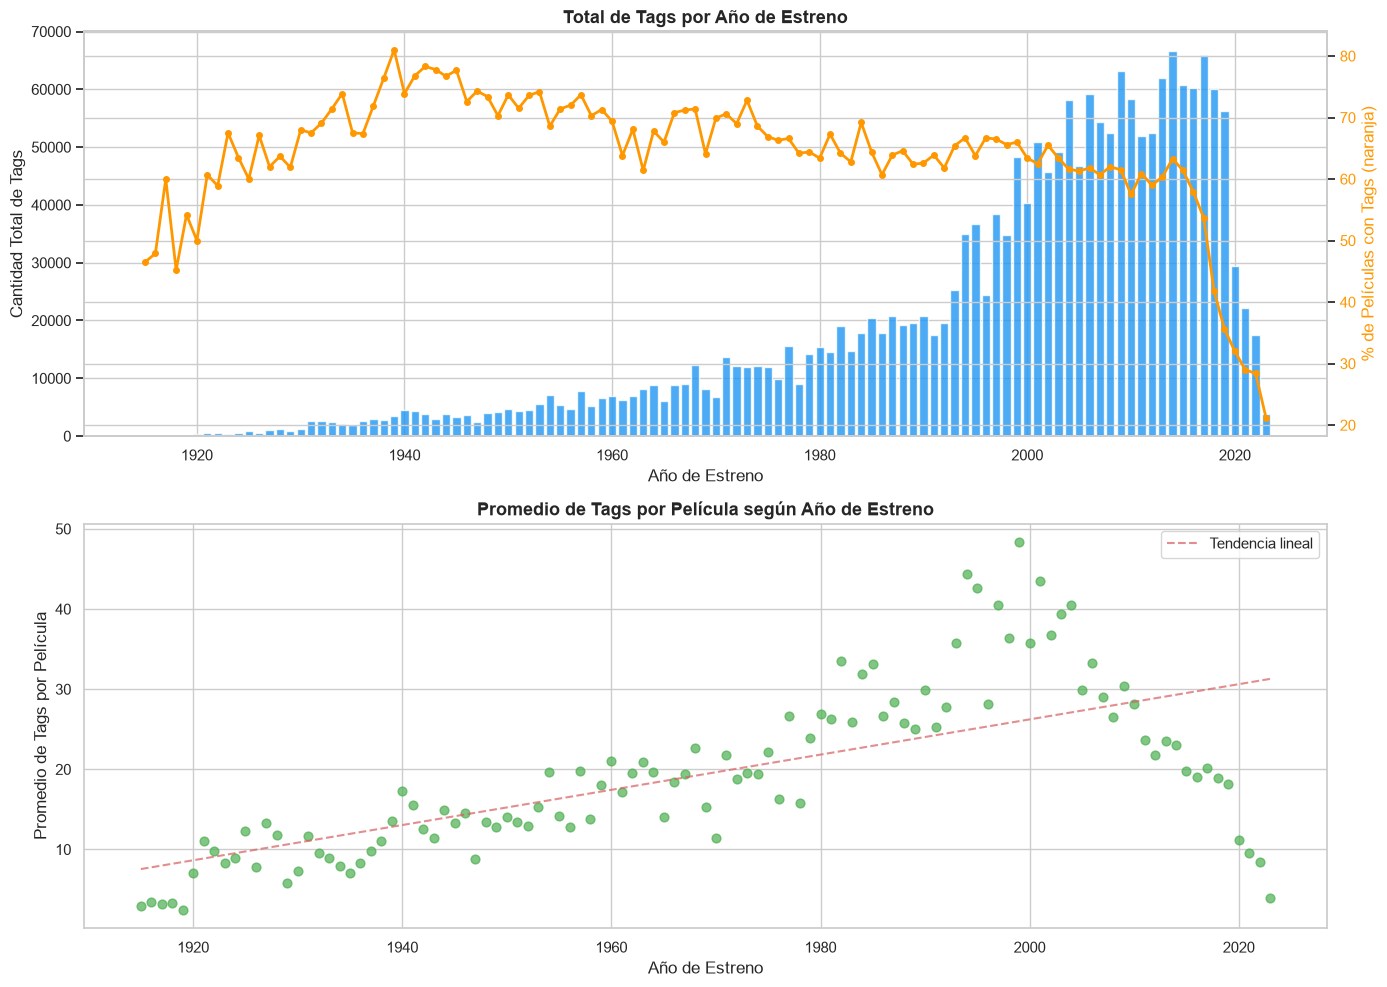

In [13]:
yearly_tags = movies_full.groupby('year').agg(
    total_tags=('total_tags', 'sum'),
    promedio_tags=('total_tags', 'mean'),
    peliculas=('movieId', 'count'),
    peliculas_con_tags=('total_tags', lambda x: (x > 0).sum())
).reset_index()

yearly_tags = yearly_tags[(yearly_tags['year'] >= 1915) & (yearly_tags['year'] <= 2023)]
yearly_tags['porcentaje_con_tags'] = (yearly_tags['peliculas_con_tags'] / yearly_tags['peliculas'] * 100).round(1)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].bar(yearly_tags['year'], yearly_tags['total_tags'], color='#2196F3', alpha=0.8, width=0.8)
axes[0].set_title('Total de Tags por Año de Estreno', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Año de Estreno')
axes[0].set_ylabel('Cantidad Total de Tags')

ax2 = axes[0].twinx()
ax2.plot(yearly_tags['year'], yearly_tags['porcentaje_con_tags'], color='#FF9800', marker='o', linewidth=2, markersize=4)
ax2.set_ylabel('% de Películas con Tags (naranja)', color='#FF9800')
ax2.tick_params(axis='y', labelcolor='#FF9800')

axes[1].scatter(yearly_tags['year'], yearly_tags['promedio_tags'], color='#4CAF50', s=40, alpha=0.7)
axes[1].set_title('Promedio de Tags por Película según Año de Estreno', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Año de Estreno')
axes[1].set_ylabel('Promedio de Tags por Película')

z = np.polyfit(yearly_tags['year'].dropna(), yearly_tags['promedio_tags'].dropna(), 1)
p = np.poly1d(z)
axes[1].plot(yearly_tags['year'], p(yearly_tags['year']), 'r--', alpha=0.7, label='Tendencia lineal')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Idea 2: Tags Exclusivos por Género

### Introducción
Cada género cinematográfico tiene características narrativas, visuales y emocionales únicas. Este análisis identifica qué **tags son exclusivos o predominantes** en ciertos géneros, revelando el vocabulario que los usuarios asocian con cada tipo de película.

### Justificación
Para un **empleado**, saber que "jump scare" es casi exclusivo de Horror permite automatizar la clasificación de contenido. Para un **usuario**, buscar por tags específicos de un género que le gusta (ej: "plot twist" en Thriller) puede descubrir películas que no habría encontrado por nombre.

In [14]:
genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
              'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

movies_tags_genres = tags.merge(
    movies_with_genres[['movieId'] + genre_cols], on='movieId', how='inner'
)

genre_tag_counts = {}
for genre in genre_cols:
    genre_movies = movies_tags_genres[movies_tags_genres[genre] == 1]
    tag_counts = genre_movies['tag'].value_counts().head(10)
    genre_tag_counts[genre] = tag_counts

tag_genre_matrix = pd.DataFrame()
for genre in genre_cols:
    top_tags = movies_tags_genres[movies_tags_genres[genre] == 1]['tag'].value_counts().head(15)
    for tag, count in top_tags.items():
        tag_genre_matrix.loc[tag, genre] = count

tag_genre_matrix = tag_genre_matrix.fillna(0)

total_per_genre = tag_genre_matrix.sum(axis=0)
tag_genre_pct = tag_genre_matrix.div(total_per_genre, axis=1) * 100

print('Top 5 tags más frecuentes por género:')
for genre in genre_cols:
    if genre in tag_genre_pct.columns:
        top5 = tag_genre_pct[genre].sort_values(ascending=False).head(5)
        tags_str = ', '.join([f'{t} ({v:.1f}%)' for t, v in top5.items()])
        print(f'  {genre:15s}: {tags_str}')

Top 5 tags más frecuentes por género:
  Action         : action (17.0%), sci-fi (15.4%), superhero (8.3%), dystopia (7.2%), visually appealing (6.5%)
  Adventure      : sci-fi (13.0%), adventure (10.4%), action (10.1%), fantasy (9.4%), superhero (7.0%)
  Animation      : animation (20.1%), anime (11.8%), Disney (9.9%), Pixar (7.7%), funny (7.5%)
  Children       : animation (15.2%), Disney (13.2%), funny (9.0%), Pixar (8.7%), family (7.6%)
  Comedy         : comedy (17.3%), funny (14.1%), dark comedy (10.1%), quirky (7.7%), black comedy (6.7%)
  Crime          : dark comedy (9.5%), twist ending (8.7%), crime (8.4%), violence (8.1%), action (7.9%)
  Documentary    : documentary (31.3%), woman director (14.0%), politics (8.9%), history (4.8%), biography (4.7%)
  Drama          : atmospheric (10.7%), surreal (8.1%), based on a book (7.3%), thought-provoking (7.2%), twist ending (7.0%)
  Fantasy        : fantasy (16.3%), surreal (10.9%), magic (8.9%), adventure (8.1%), based on a book (6.4

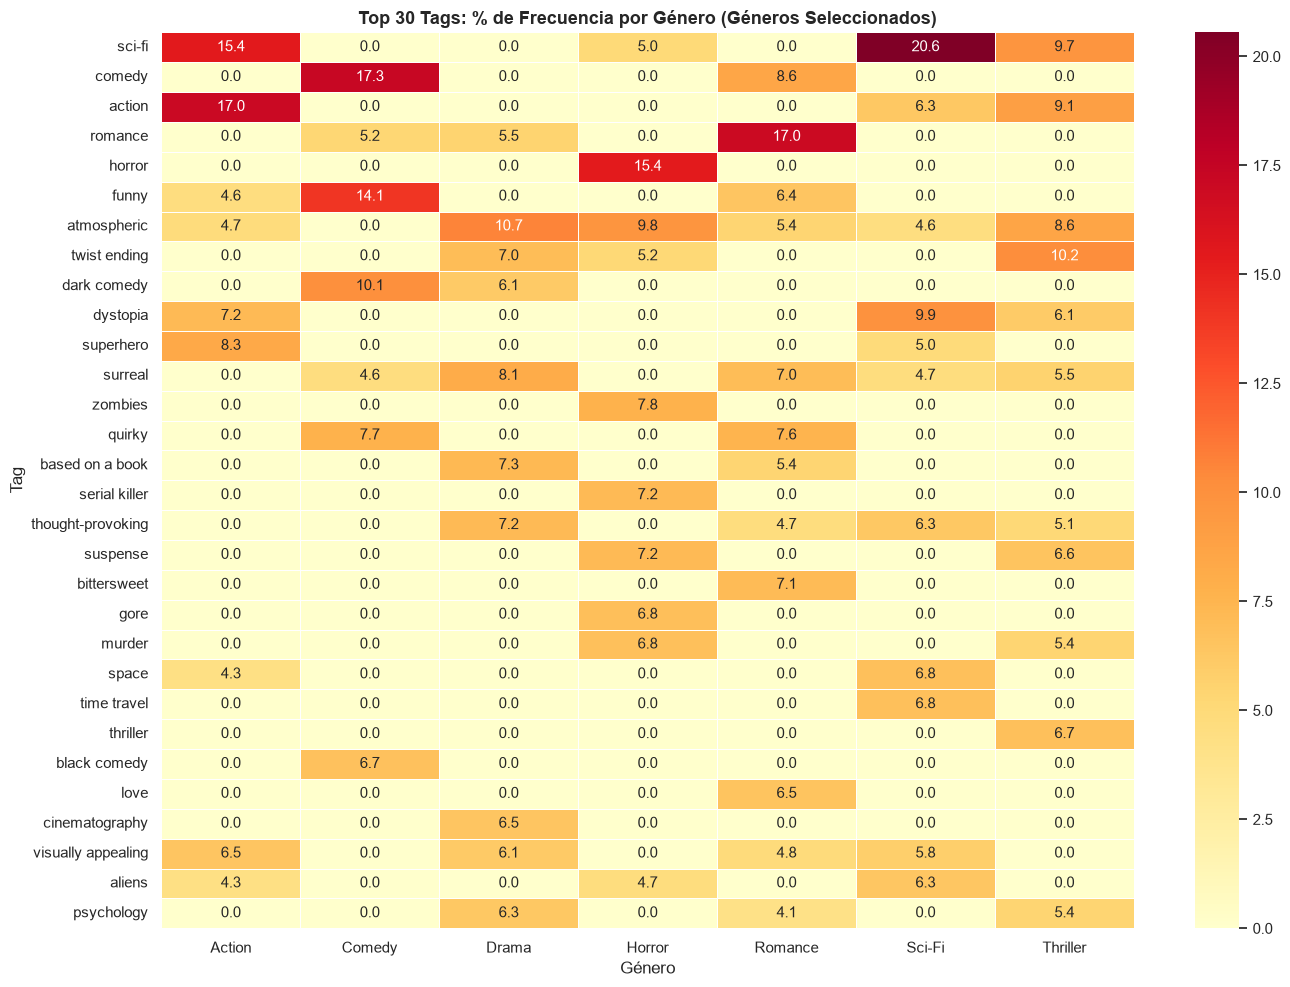

In [15]:
selected_genres = ['Action', 'Comedy', 'Drama', 'Horror', 'Romance', 'Sci-Fi', 'Thriller']
heatmap_data = tag_genre_pct[selected_genres].loc[
    tag_genre_pct[selected_genres].max(axis=1).sort_values(ascending=False).head(30).index
]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Top 30 Tags: % de Frecuencia por Género (Géneros Seleccionados)', fontsize=13, fontweight='bold')
ax.set_xlabel('Género')
ax.set_ylabel('Tag')
plt.tight_layout()
plt.show()

---
## Idea 4: Películas Más vs Menos Etiquetadas

### Introducción
No todas las películas generan la misma cantidad de interacción. Algunas reciben cientos de tags mientras que otras reciben solo uno o dos. Este análisis presenta las **películas más y menos etiquetadas** para entender qué tipo de contenido genera más discusión.

### Justificación
Para un **empleado**, las películas con muchos tags son candidatas para promoción (generan engagement). Para un **usuario**, una película con muchos tags tiene más información disponible para decidir si verla o no.

In [16]:
movies_sorted = movies_full.sort_values('total_tags', ascending=False)

print('Top 15 películas con MÁS tags:')
top_movies = movies_sorted.head(15)[['title', 'year', 'total_tags', 'tags_unicos']]
top_movies.index = range(1, 16)
display(top_movies.style.background_gradient(subset=['total_tags', 'tags_unicos'], cmap='Greens'))

print('\nTop 15 películas con MENOS tags (de las que tienen al menos 1):')
bottom_movies = movies_sorted[movies_sorted['total_tags'] > 0].tail(15)[['title', 'year', 'total_tags', 'tags_unicos']]
bottom_movies.index = range(1, 16)
display(bottom_movies.style.background_gradient(subset=['total_tags', 'tags_unicos'], cmap='Reds'))

Top 15 películas con MÁS tags:


,title,year,total_tags,tags_unicos
1,Pulp Fiction,1994.000000,6697,944
2,Inception,2010.000000,6568,242
3,Star Wars: Episode IV - A New Hope,1977.000000,6519,1109
4,"Matrix, The",1999.000000,5722,638
5,Fight Club,1999.000000,5532,633
6,Interstellar,2014.000000,5477,268
7,"Shawshank Redemption, The",1994.000000,4892,772
8,Memento,2000.000000,3808,349
9,Eternal Sunshine of the Spotless Mind,2004.000000,3683,411
10,Forrest Gump,1994.000000,3581,747



Top 15 películas con MENOS tags (de las que tienen al menos 1):


,title,year,total_tags,tags_unicos
1,Grave of the Vampire,1972.000000,1,1
2,Honeydripper,2007.000000,1,1
3,Lost Islands,2008.000000,1,1
4,Gunnin' for That #1 Spot,2008.000000,1,1
5,Ladies in Black,2018.000000,1,1
6,Longshot,1981.000000,1,1
7,De feu et de glace,2008.000000,1,1
8,The Librarians (Strike Force),2004.000000,1,1
9,Remarkable Power,2008.000000,1,1
10,Craig Ferguson: Tickle Fight,2017.000000,1,1


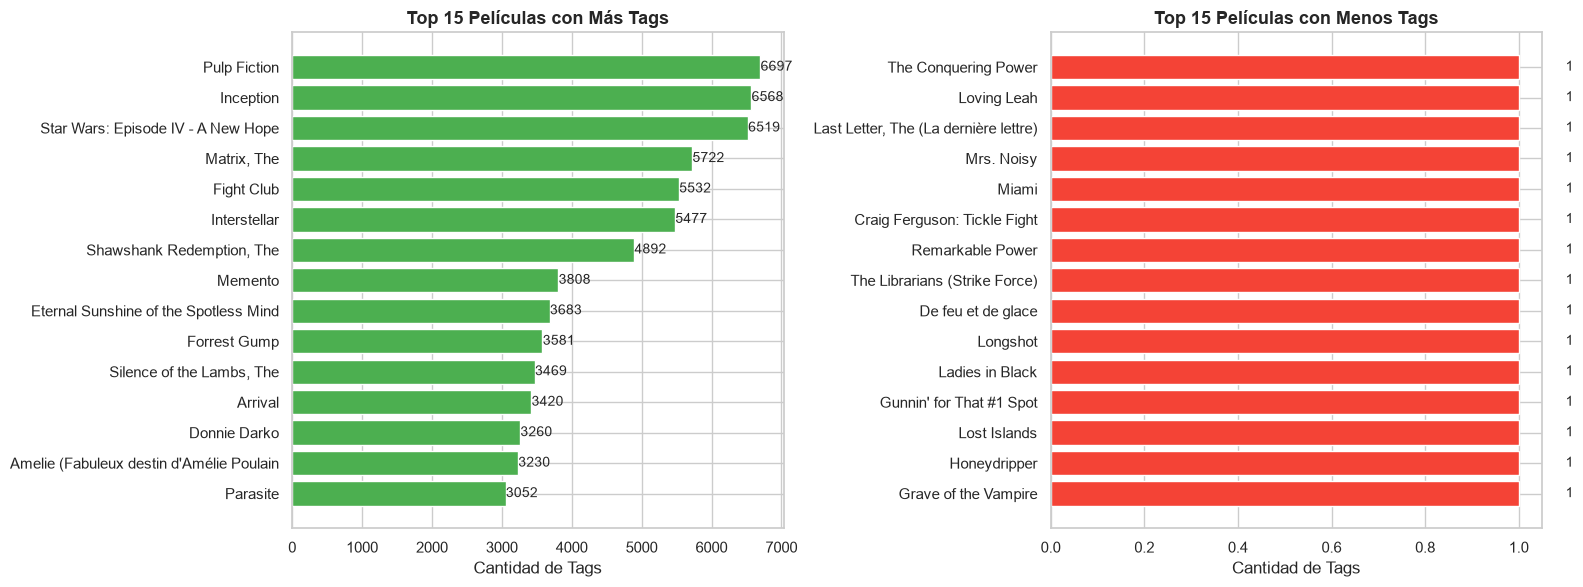

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top15 = movies_sorted.head(15)
axes[0].barh(top15['title'].str[:40], top15['total_tags'], color='#4CAF50', edgecolor='white')
axes[0].set_title('Top 15 Películas con Más Tags', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de Tags')
axes[0].invert_yaxis()
for i, v in enumerate(top15['total_tags']):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

bottom15 = movies_sorted[movies_sorted['total_tags'] > 0].tail(15).sort_values('total_tags', ascending=True)
axes[1].barh(bottom15['title'].str[:40], bottom15['total_tags'], color='#F44336', edgecolor='white')
axes[1].set_title('Top 15 Películas con Menos Tags', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cantidad de Tags')
for i, v in enumerate(bottom15['total_tags']):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## Idea 5: Géneros con Mayor Diversidad de Tags

### Introducción
¿Algunos géneros reciben una gama más amplia de tags que otros? Este análisis mide la **diversidad de vocabulario** en los tags de cada género, revelando cuáles generan opiniones más variadas y cuáles son más predecibles.

### Justificación
Para un **empleado**, un género con alta diversidad de tags (ej: Drama) indica que el contenido es más subjetivo y genera opiniones variadas, lo cual es importante para estrategia de recomendación. Para un **usuario**, géneros con baja diversidad (ej: Children) tienen tags más predecibles, lo que facilita la búsqueda.

In [18]:
genre_diversity = {}
for genre in genre_cols:
    genre_movies = movies_tags_genres[movies_tags_genres[genre] == 1]
    unique_tags = genre_movies['tag'].nunique()
    total_tags = len(genre_movies)
    movies_count = genre_movies['movieId'].nunique()
    genre_diversity[genre] = {
        'tags_unicos': unique_tags,
        'total_tags': total_tags,
        'peliculas': movies_count,
        'tags_por_pelicula': total_tags / movies_count if movies_count > 0 else 0,
        'diversidad': unique_tags / total_tags if total_tags > 0 else 0
    }

genre_div_df = pd.DataFrame(genre_diversity).T.sort_values('diversidad', ascending=False)

print('Diversidad de tags por género:')
display(genre_div_df.style.background_gradient(subset=['diversidad', 'tags_por_pelicula'], cmap='viridis'))

Diversidad de tags por género:


,tags_unicos,total_tags,peliculas,tags_por_pelicula,diversidad
Documentary,15791.000000,52720.000000,4703.000000,11.209866,0.299526
Film-Noir,6563.000000,24666.000000,344.000000,71.703488,0.266075
Musical,10679.000000,42556.000000,1009.000000,42.176412,0.250940
Western,7590.000000,30340.000000,1323.000000,22.932729,0.250165
War,16580.000000,86768.000000,1620.000000,53.560494,0.191084
Children,17255.000000,92812.000000,2464.000000,37.667208,0.185913
Animation,18800.000000,109377.000000,2457.000000,44.516484,0.171883
Horror,38998.000000,263092.000000,5490.000000,47.922040,0.148230
Fantasy,29198.000000,201105.000000,2539.000000,79.206380,0.145188
Mystery,27276.000000,191255.000000,2606.000000,73.390253,0.142616


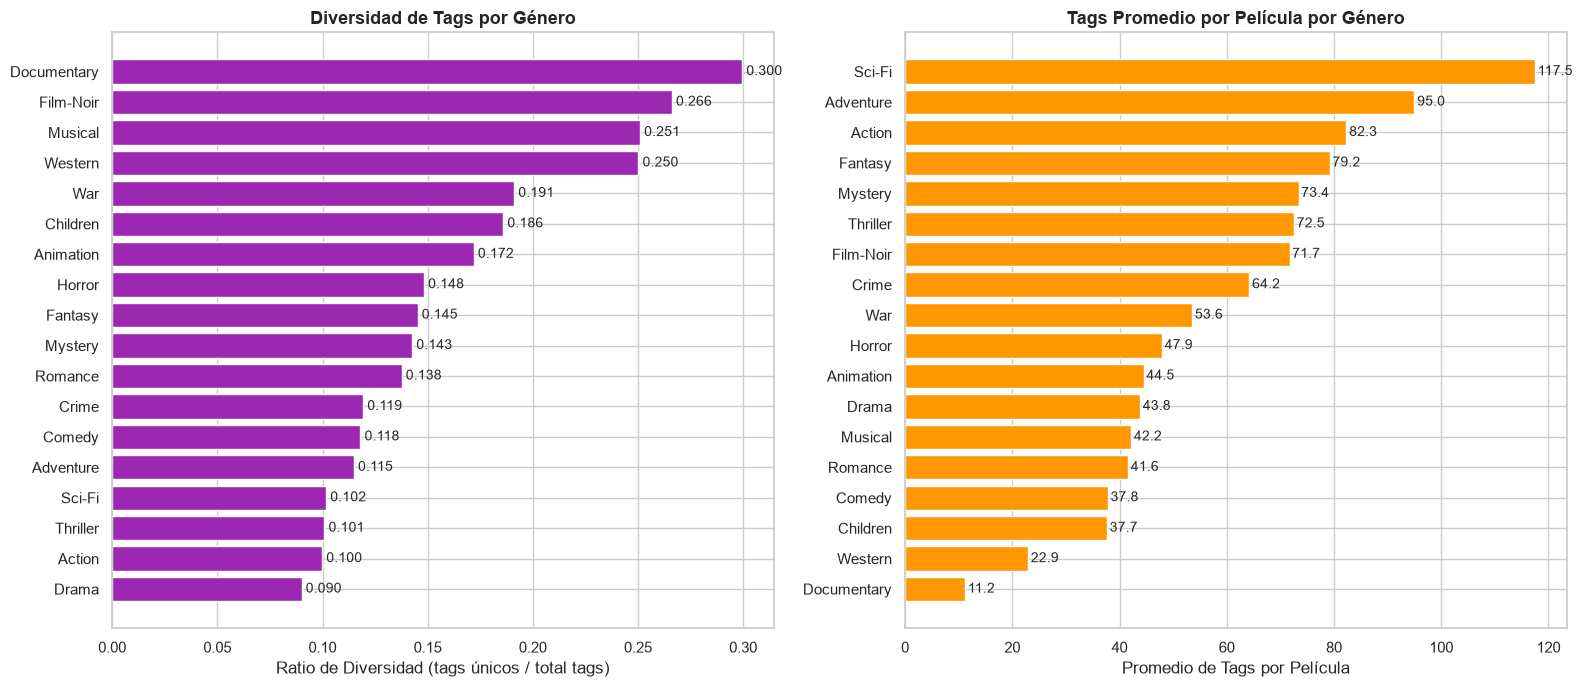

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

genre_div_sorted = genre_div_df.sort_values('diversidad', ascending=True)
axes[0].barh(genre_div_sorted.index, genre_div_sorted['diversidad'], color='#9C27B0', edgecolor='white')
axes[0].set_title('Diversidad de Tags por Género', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ratio de Diversidad (tags únicos / total tags)')
for i, v in enumerate(genre_div_sorted['diversidad']):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

genre_tags_sorted = genre_div_df.sort_values('tags_por_pelicula', ascending=True)
axes[1].barh(genre_tags_sorted.index, genre_tags_sorted['tags_por_pelicula'], color='#FF9800', edgecolor='white')
axes[1].set_title('Tags Promedio por Película por Género', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Promedio de Tags por Película')
for i, v in enumerate(genre_tags_sorted['tags_por_pelicula']):
    axes[1].text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## Idea 6: Distribución de Tags por Década

### Introducción
El vocabulario de los usuarios para describir películas cambia con el tiempo. Este análisis muestra cómo se distribuyen los tags por **década de estreno**, revelando qué tipos de películas de cada era son más discutidas y qué tags eran más populares.

### Justificación
Para un **empleado**, ver que los años 2000-2010 tienen más tags puede indicar una era de mayor actividad de usuarios. Para un **usuario**, ver qué tags son populares por década puede ayudarle a descubrir películas clásicas con descripciones atractivas.

In [20]:
movies_tags_decada = tags.merge(movies[['movieId', 'decada']], on='movieId', how='inner')
movies_tags_decada = movies_tags_decada[movies_tags_decada['decada'].notna()]

decada_stats = movies_tags_decada.groupby('decada').agg(
    total_tags=('tag', 'count'),
    tags_unicos=('tag', 'nunique'),
    peliculas=('movieId', 'nunique')
).reset_index()

decada_stats['tags_por_pelicula'] = (decada_stats['total_tags'] / decada_stats['peliculas']).round(1)
decada_stats['diversidad'] = (decada_stats['tags_unicos'] / decada_stats['total_tags']).round(3)

print('Estadísticas por década:')
display(decada_stats.style.background_gradient(subset=['total_tags', 'tags_por_pelicula'], cmap='Blues'))

Estadísticas por década:


,decada,total_tags,tags_unicos,peliculas,tags_por_pelicula,diversidad
0,1870.000000,17,14,2,8.500000,0.824000
1,1880.000000,36,25,6,6.000000,0.694000
2,1890.000000,558,249,129,4.300000,0.446000
3,1900.000000,585,287,121,4.800000,0.491000
4,1910.000000,956,554,185,5.200000,0.579000
5,1920.000000,6859,3102,452,15.200000,0.452000
6,1930.000000,24636,8992,1852,13.300000,0.365000
7,1940.000000,36978,12317,2072,17.800000,0.333000
8,1950.000000,55894,16589,2604,21.500000,0.297000
9,1960.000000,81633,21266,2939,27.800000,0.261000


In [21]:
decadas = sorted(movies_tags_decada['decada'].unique())
decadas = [d for d in decadas if d >= 1950]

top_tags_per_decade = {}
for decada in decadas:
    decada_tags = movies_tags_decada[movies_tags_decada['decada'] == decada]['tag'].value_counts().head(5)
    top_tags_per_decade[int(decada)] = decada_tags

print('Top 5 tags por década:')
for decada, tag_counts in top_tags_per_decade.items():
    tags_str = ', '.join([f'{t} ({c})' for t, c in tag_counts.items()])
    print(f'  {int(decada)}s: {tags_str}')

Top 5 tags por década:
  1950s: BD-R (751), classic (424), Criterion (348), black and white (315), film noir (298)
  1960s: BD-R (709), classic (534), Criterion (522), atmospheric (461), murder (290)
  1970s: classic (972), sci-fi (902), atmospheric (874), cult film (579), murder (498)
  1980s: sci-fi (1158), classic (1013), comedy (913), cult film (873), atmospheric (804)
  1990s: dark comedy (2277), twist ending (1767), sci-fi (1671), atmospheric (1611), surreal (1562)
  2000s: atmospheric (3028), comedy (2885), twist ending (2851), sci-fi (2845), surreal (2566)
  2010s: sci-fi (3866), visually appealing (3744), action (3226), cinematography (2948), funny (2893)
  2020s: action (446), visually appealing (352), sci-fi (343), funny (289), cinematography (278)


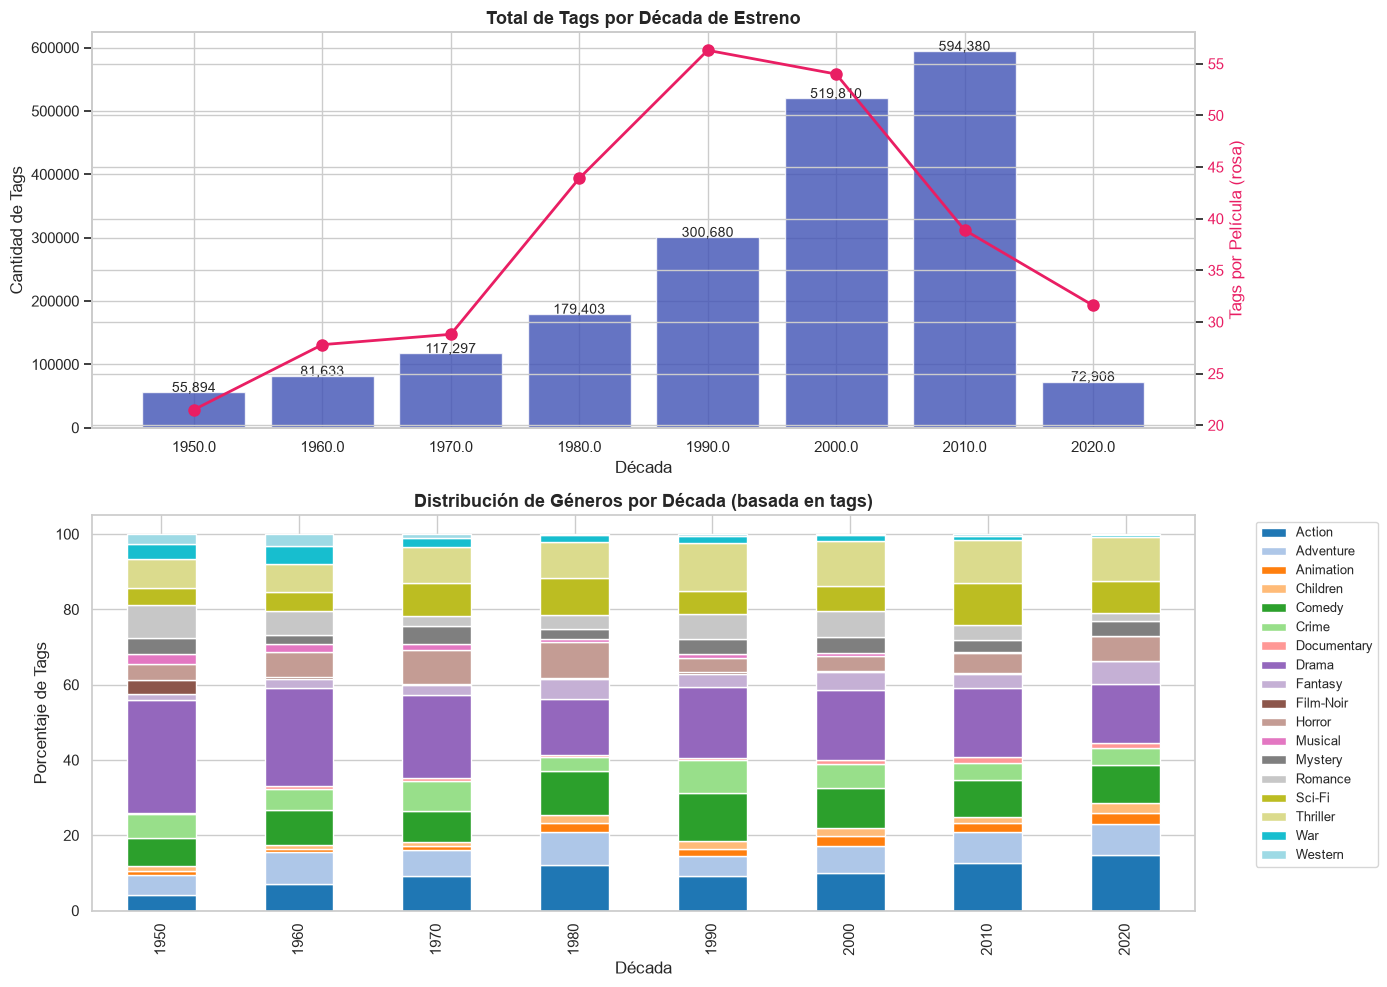

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

decada_data = decada_stats[decada_stats['decada'] >= 1950]

axes[0].bar(decada_data['decada'].astype(str), decada_data['total_tags'], color='#3F51B5', alpha=0.8)
axes[0].set_title('Total de Tags por Década de Estreno', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Década')
axes[0].set_ylabel('Cantidad de Tags')
for i, v in enumerate(decada_data['total_tags']):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

ax2 = axes[0].twinx()
ax2.plot(decada_data['decada'].astype(str), decada_data['tags_por_pelicula'], color='#E91E63', marker='o', linewidth=2, markersize=8)
ax2.set_ylabel('Tags por Película (rosa)', color='#E91E63')
ax2.tick_params(axis='y', labelcolor='#E91E63')

decada_genre = movies_tags_decada.merge(
    movies_with_genres[['movieId'] + genre_cols], on='movieId', how='inner'
)

genre_by_decade = pd.DataFrame()
for decada in decadas:
    dec_data = decada_genre[decada_genre['decada'] == decada]
    for genre in genre_cols:
        genre_by_decade.loc[decada, genre] = dec_data[genre].sum()

genre_by_decade_pct = genre_by_decade.div(genre_by_decade.sum(axis=1), axis=0) * 100
genre_by_decade_pct = genre_by_decade_pct[genre_by_decade_pct.index >= 1950]

genre_by_decade_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Distribución de Géneros por Década (basada en tags)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Década')
axes[1].set_ylabel('Porcentaje de Tags')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## Idea 7: Películas con Tags Contradictorios

### Introducción
Algunas películas generan opiniones divididas: un usuario las llama "masterpiece" mientras otro las llama "overrated". Este análisis identifica las **películas más polémicas**, aquellas que tienen tanto tags positivos como negativos en proporciones similares.

### Justificación
Para un **empleado**, las películas contradictorias son ideal para promoción debates y engagement. Para un **usuario**, saber que una película es polémica puede ser un llamado a formar su propia opinión, o evitarla si prefiere consenso.

In [23]:
tags_positivos = ['masterpiece', 'brilliant', 'amazing', 'excellent', 'outstanding',
                  'perfect', 'beautiful', 'incredible', 'wonderful', 'fantastic',
                  'great', 'awesome', 'superb', 'magnificent', 'best movie ever',
                  'highly recommend', 'must see', 'classic', 'gem', 'underrated']

tags_negativos = ['boring', 'terrible', 'awful', 'bad', 'worst', 'disappointing',
                  'overrated', 'waste of time', 'poor', 'dull', 'mediocre',
                  'predictable', 'annoying', 'horrible', 'stupid', 'bad acting',
                  'plot hole', 'unrealistic', 'cliche', 'cheesy']

def classify_tag(tag):
    tag_lower = tag.lower()
    if tag_lower in tags_positivos:
        return 'positivo'
    elif tag_lower in tags_negativos:
        return 'negativo'
    return 'neutro'

tags = tags.dropna(subset=['tag'])
tags['sentimiento'] = tags['tag'].apply(classify_tag)

movie_sentiment = tags.groupby(['movieId', 'sentimiento']).size().unstack(fill_value=0)
movie_sentiment = movie_sentiment.reset_index()

if 'positivo' not in movie_sentiment.columns:
    movie_sentiment['positivo'] = 0
if 'negativo' not in movie_sentiment.columns:
    movie_sentiment['negativo'] = 0

movie_sentiment['total_sentiment'] = movie_sentiment['positivo'] + movie_sentiment['negativo']
movie_sentiment = movie_sentiment[movie_sentiment['total_sentiment'] >= 3]

movie_sentiment['ratio_pos'] = movie_sentiment['positivo'] / movie_sentiment['total_sentiment']
movie_sentiment['polaridad'] = abs(movie_sentiment['ratio_pos'] - 0.5)

contradictorias = movie_sentiment.sort_values('polaridad', ascending=True).head(20)
contradictorias = contradictorias.merge(movies[['movieId', 'title', 'year']], on='movieId')

print('Top 20 películas más contradictorias (menor polaridad = más divididas):')
display(contradictorias[['title', 'year', 'positivo', 'negativo', 'total_sentiment', 'ratio_pos', 'polaridad']].style.background_gradient(subset=['polaridad'], cmap='RdYlGn_r'))

Top 20 películas más contradictorias (menor polaridad = más divididas):


,title,year,positivo,negativo,total_sentiment,ratio_pos,polaridad
0,Spirit: Stallion of the Cimarron,2002.000000,2,2,4,0.500000,0.000000
1,"Boondock Saints, The",2000.000000,2,2,4,0.500000,0.000000
2,Frailty,2001.000000,4,4,8,0.500000,0.000000
3,Moulin Rouge,2001.000000,2,2,4,0.500000,0.000000
4,Dogville,2003.000000,4,4,8,0.500000,0.000000
5,Monty Python's Life of Brian,1979.000000,2,2,4,0.500000,0.000000
6,"Wind Rises, The (Kaze tachinu)",2013.000000,3,3,6,0.500000,0.000000
7,Batman Begins,2005.000000,2,2,4,0.500000,0.000000
8,Sin City,2005.000000,7,7,14,0.500000,0.000000
9,Pete's Dragon,1977.000000,2,2,4,0.500000,0.000000


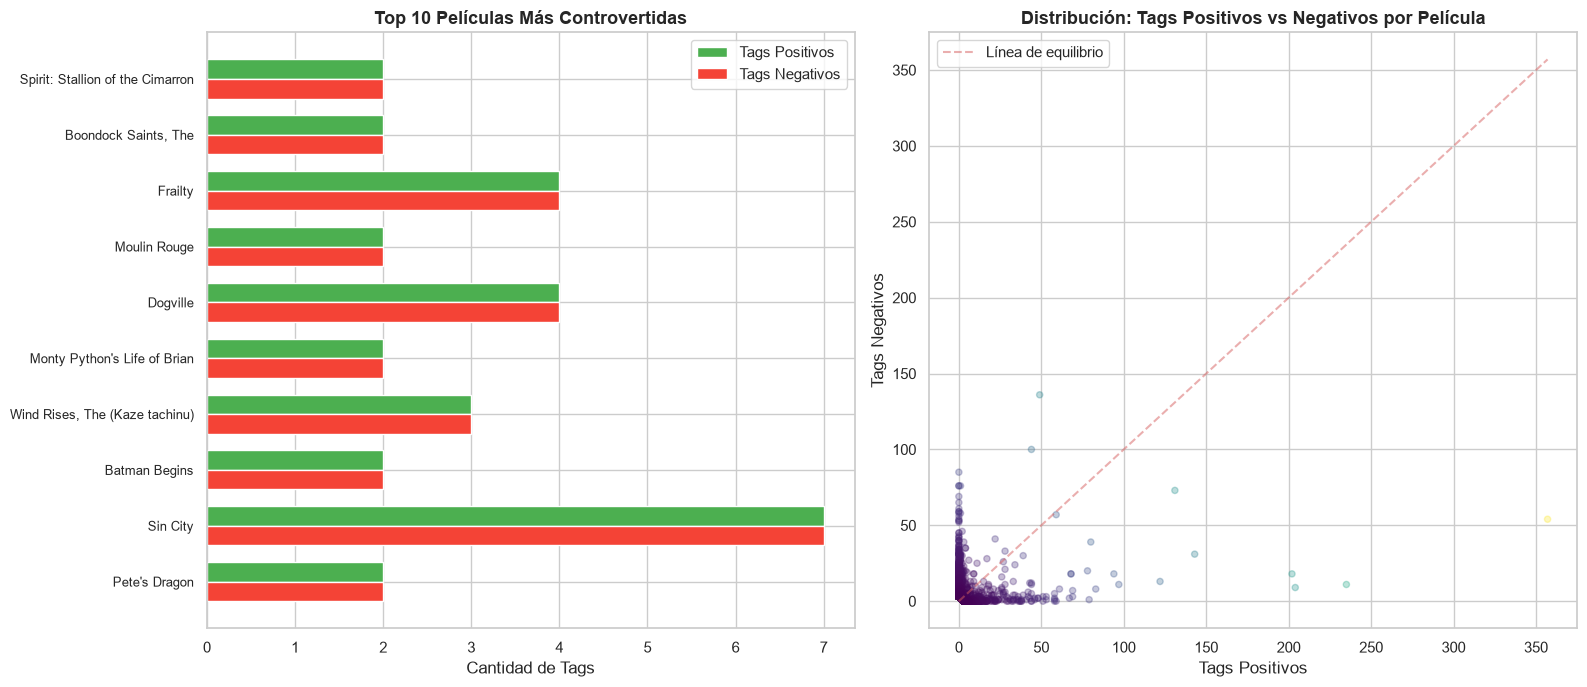

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top10_controversial = contradictorias.head(10)
labels = [f"{t[:35]}..." if len(t) > 35 else t for t in top10_controversial['title']]

x = np.arange(len(labels))
width = 0.35

axes[0].barh(x - width/2, top10_controversial['positivo'], width, label='Tags Positivos', color='#4CAF50')
axes[0].barh(x + width/2, top10_controversial['negativo'], width, label='Tags Negativos', color='#F44336')
axes[0].set_yticks(x)
axes[0].set_yticklabels(labels, fontsize=9)
axes[0].set_title('Top 10 Películas Más Controvertidas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de Tags')
axes[0].legend()
axes[0].invert_yaxis()

all_sentiment = movie_sentiment.merge(movies[['movieId', 'title']], on='movieId')
all_sentiment = all_sentiment[all_sentiment['total_sentiment'] >= 3]

axes[1].scatter(all_sentiment['positivo'], all_sentiment['negativo'],
                alpha=0.3, s=20, c=all_sentiment['total_sentiment'], cmap='viridis')
axes[1].plot([0, all_sentiment['positivo'].max()], [0, all_sentiment['positivo'].max()],
             'r--', alpha=0.5, label='Línea de equilibrio')
axes[1].set_title('Distribución: Tags Positivos vs Negativos por Película', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tags Positivos')
axes[1].set_ylabel('Tags Negativos')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Idea 8: Densidad de Tags por Género (Violin Plot)

### Introducción
Mientras los gráficos de barras muestran promedios, un **violin plot** revela la distribución completa de datos. Este análisis muestra cómo se distribuye la cantidad de tags por película en cada género, permitiendo ver si hay géneros con distribuciones más uniformes o con valores atípicos.

### Justificación
Para un **empleado**, ver que Drama tiene una distribución amplia indica que algunas películas de Drama son muy discutidas mientras otras pasan desapercibidas. Para un **usuario**, un género con distribución concentrada (ej: Children) significa que la mayoría de películas tienen cantidades similares de información disponible.

C:\Users\ACER\AppData\Local\Temp\ipykernel_24084\2035774859.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=genre_tags_df, x='Género', y='Tags por Película',


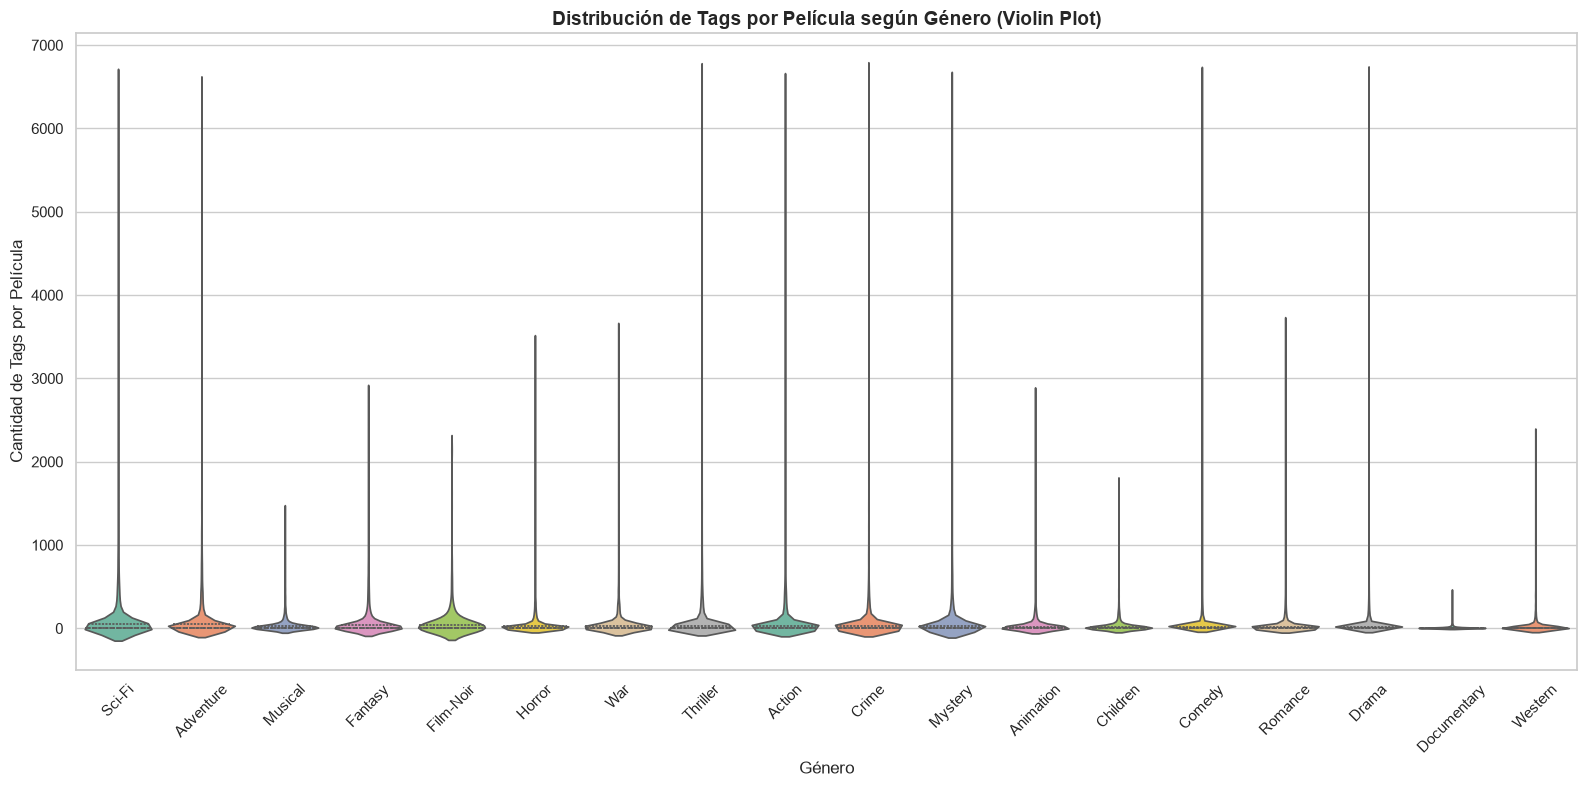

In [25]:
# Crear dataset movieId-género con tags por película
movies_full_with_genres = movies_full[['movieId', 'total_tags']].merge(
    movies_with_genres[['movieId'] + genre_cols], on='movieId', how='inner'
)
movies_full_with_genres = movies_full_with_genres[movies_full_with_genres['total_tags'] > 0]

# Explodar géneros para tener una fila por género por película
genre_melted = movies_full_with_genres.melt(
    id_vars=['movieId', 'total_tags'], value_vars=genre_cols,
    var_name='Género', value_name='tiene'
)
genre_melted = genre_melted[genre_melted['tiene'] == 1].drop(columns=['tiene'])

genre_tags_df = genre_melted[['Género', 'total_tags']].rename(columns={'total_tags': 'Tags por Película'})

genre_order = genre_tags_df.groupby('Género')['Tags por Película'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(data=genre_tags_df, x='Género', y='Tags por Película',
               order=genre_order, palette='Set2', inner='quartile', ax=ax)
ax.set_title('Distribución de Tags por Película según Género (Violin Plot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Género', fontsize=12)
ax.set_ylabel('Cantidad de Tags por Película', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [26]:
genre_stats_summary = genre_tags_df.groupby('Género')['Tags por Película'].agg(
    ['median', 'mean', 'std', 'min', 'max', 'count']
).round(1)
genre_stats_summary = genre_stats_summary.sort_values('median', ascending=False)

print('Estadísticas descriptivas de tags por película según género:')
display(genre_stats_summary.style.background_gradient(subset=['median', 'mean'], cmap='YlOrRd'))

Estadísticas descriptivas de tags por película según género:


,median,mean,std,min,max,count
Género,,,,,,
Sci-Fi,10.000000,117.500000,377.300000,1,6568,3422
Adventure,9.000000,95.000000,276.800000,1,6519,3812
Musical,9.000000,42.200000,107.100000,1,1425,1009
Fantasy,9.000000,79.200000,219.600000,1,2831,2539
Film-Noir,9.000000,71.700000,224.300000,1,2180,344
Horror,8.000000,47.900000,141.000000,1,3469,5490
War,8.000000,53.600000,186.600000,1,3581,1620
Thriller,8.000000,72.500000,257.600000,1,6697,7606
Action,7.000000,82.300000,278.400000,1,6568,6290


---
## Conclusiones y Beneficios

### Beneficios para el Usuario

| Análisis | Beneficio |
|---|---|
| **Año vs Tags** | Puede identificar qué películas recientes generan más discusión y tienen más información disponible para tomar decisiones. |
| **Tags exclusivos por género** | Le permite buscar películas por tags específicos de un género que le interesa (ej: "plot twist" en Thriller), descubriendo contenido que no encontraría por nombre. |
| **Películas más/menos etiquetadas** | Las películas con más tags tienen más descripciones de usuarios, facilitando la decisión de verlas o no. |
| **Tags contradictorios** | Si una película tiene opiniones divididas, el usuario puede decidir si quiere formar su propia opinión o evitar la controversia. |
| **Densidad por género** | Le muestra qué géneros tienen la mayor variedad de descripciones, ayudándole a explorar nuevos tipos de contenido. |

### Beneficios para el Empleado

| Análisis | Beneficio |
|---|---|
| **Año vs Tags** | Revela tendencias de engagement por era cinematográfica, útil para estrategia de catálogo y adquisición de contenido. |
| **Tags exclusivos por género** | Permite automatizar la clasificación de contenido usando tags como features de machine learning. |
| **Películas más/menos etiquetadas** | Identifica candidates para promoción (muchos tags = alto engagement) y contenido que necesita más visibilidad (pocos tags). |
| **Géneros con diversidad de tags** | Entender qué géneros generan opiniones más variadas ayuda a calibrar sistemas de recomendación. |
| **Distribución por década** | Muestra cómo evoluciona el vocabulario de usuarios, útil para actualizar taxonomías de tags. |
| **Tags contradictorios** | Las películas polémicas son ideales para campañas de marketing basadas en debate y engagement. |
| **Densidad por género** | La distribución completa revela patrones que los promedios ocultan, como películas atípicamente discutidas. |

### Hallazgos Clave
1. **El engagement con tags crece con el tiempo**: Películas más recientes tienden a recibir más tags, reflejando mayor actividad de usuarios.
2. **Cada género tiene vocabulario propio**: Los tags no son universales; cada género tiene etiquetas predominantes que lo caracterizan.
3. **Existen películas polémicas**: Algunas películas generan opiniones fuertemente divididas, lo cual es valioso para engagement.
4. **La diversidad varía entre géneros**: Géneros como Drama y Thriller tienen mayor variedad de opiniones que Children o Animation.
5. **Los tags son un recurso de clasificación automatizada**: La relación entre tags y géneros permite construir sistemas de recomendación más precisos.
6. **La distribución completa importa**: Los violin plots revelan que los promedios pueden ser engañosos; la dispersión de datos es igualmente informativa.